# Notebook preparation

### Import libraries

In [3]:
%matplotlib inline
import os
import sys
import csv
import time
import torch
import pathlib
import matplotlib
import numpy as np
import pandas as pd
import seaborn as sb
from scipy.stats import binned_statistic_2d

### Import Autoencoder class

In [5]:
folder_path = str(pathlib.Path().resolve().parents[1])
print("Folder path =", folder_path)

data_path = 'D:\HPC-VTA_autoencoder_data\DoubleTmazeDataset\DoubleTmazeNoReward'
plot_folder_path = str(pathlib.Path()) + '/Plots'
model_folder_path = folder_path + '/Models/'
loss_csv_filename = model_folder_path + '/loss_history.csv'

sys.path.append(folder_path + '/Notebooks/AE_class')
from Conv_AE_weebots_downsampled import *

Folder path = C:\Users\specs\Desktop\Robotology\Repos\HPC-VTA_Autoencoder


### Check libraries versions

In [7]:
print(f"torch version: {torch.__version__}")
print(f"numpy version: {np.__version__}")
print(f"matplotlib version: {matplotlib.__version__}")
print(f"seaborn version: {sb.__version__}")

torch version: 2.2.1+cu121
numpy version: 1.26.4
matplotlib version: 3.8.0
seaborn version: 0.12.2


### Check GPU

In [9]:
print("CUDA is available =", torch.cuda.is_available())
print("CUDA device count =", torch.cuda.device_count())
if torch.cuda.device_count() > 1:
    os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'
#print(torch.cuda.current_device())
#print(torch.cuda.device(0))
print("CUDA device name =", torch.cuda.get_device_name(0))

CUDA is available = True
CUDA device count = 2
CUDA device name = NVIDIA RTX A5000


## Autoencoder Hyperparameters

In [11]:
#Experiment
model_training = False
model_saving = True
save_plots = True

#Model
n_hidden = 400
batch_size = 256
num_epochs = 200
learning_rate = 1e-4
C_factor = 1e3
alpha = 1e5

#Others
peak_as_centroid=True
min_pix_cluster=0.02
max_pix_cluster=0.5
active_threshold=0.2

In [12]:
model_filename =  'DoubleTmaze-Epochs' + str(num_epochs) + '-NHidden' + str(n_hidden) + '-BSize' + str(batch_size) + '-C' + str(C_factor) + '-A' + str(alpha) + '-LR' + str(learning_rate) + '.pth'
model_path = model_folder_path + model_filename
loss_csv_filename = model_folder_path + '/' + model_filename[:-4] + '_loss_history.csv'

### Function

In [14]:
def format_dataset(data_path):
    csv_filename = data_path + "/data.csv"

    img_filename_list = os.listdir(data_path)
    num_images = len(img_filename_list) -1 

    return csv_filename, num_images
#####################################################################

def load_csv(csv_filename):
    data = pd.read_csv(csv_filename)
    data = data[:num_images]
    position = [] 
    pos_step = []
    orientation = []
    
    for i in range(len(data)):
        pos_step = [data.X[i], data.Y[i]]
        position.append(pos_step)
        z = data.Z[i]
        orientation.append(z)
        
    position = np.array(position)
    orientation = np.array(orientation)
    
    return data, position, orientation
#####################################################################

def save_training_loss(loss_csv_filename, loss):
    with open(loss_csv_filename, mode='w', newline='') as file:
        writer = csv.writer(file)
        writer.writerow(['Image_loss'])
    
        # If you want each element on a new line
        for item in loss:
            writer.writerow([item])
    print("Loss History saved at", loss_csv_filename)
#####################################################################

def check_missing_frame(dataframe):
    img_idx = 1
    frames_to_remove = []
    for i in range(len(dataframe['Frame_ID'])):    
        if dataframe['Frame_ID'][i] != i+img_idx:
            frames_to_remove.append(i)
            img_idx += 1
    print("Frames ID to be removed from dataset =", frames_to_remove)
    return frames_to_remove
#####################################################################

def clean_dataset(dataset, frames_to_remove):
    dataset = np.delete(dataset, frames_to_remove, axis=0)
    return dataset

# Import No Reward DoubleTMaze image dataset and CSV data

In [16]:
csv_filename, num_images = format_dataset(data_path)

print("Num. Images in Dataset =", num_images)
print("Dataset Path =", data_path)
print("CSV path =    ", csv_filename)

Num. Images in Dataset = 40001
Dataset Path = D:\HPC-VTA_autoencoder_data\DoubleTmazeDataset\DoubleTmazeNoReward
CSV path =     D:\HPC-VTA_autoencoder_data\DoubleTmazeDataset\DoubleTmazeNoReward/data.csv


In [17]:
noReward_DTmaze_data, noReward_DTmaze_position, noReward_DTmaze_orientation = load_csv(csv_filename)
noReward_dataset = load_dataset(data_path)  # this array should have shape (n_samples, 3, 120, 160)

frames_to_remove = check_missing_frame(noReward_DTmaze_data)
noReward_dataset = clean_dataset(noReward_dataset, frames_to_remove)

print("Dataset Shape =", noReward_dataset.shape)
print("Position Shape =", noReward_DTmaze_position.shape)
print()
noReward_DTmaze_data

Frames ID to be removed from dataset = [19681]
Dataset Shape = (39999, 120, 160, 3)
Position Shape = (39999, 2)



,Trial_number,Trial_time,Frame_ID,Embedding,action,retrieved_action,X,Y,Z,Internal_states,RewardID,Reward_value,n_replays
0,0,1.024,1,[],"[0, 0]",False,-0.000008,-0.009500,270.045416,"[0.499, 0.999, 0.999, 0.999]",0,"[0, 0, 0, 0]",0
1,0,2.048,2,[],"[4.71, 6.28]",False,0.020396,0.090619,298.177441,"[0.498, 0.998, 0.998, 0.998]",0,"[0, 0, 0, 0]",0
2,0,3.072,3,[],"[0.0, 1.57]",False,0.029349,0.108280,330.537874,"[0.497, 0.997, 0.997, 0.997]",0,"[0, 0, 0, 0]",0
3,0,4.096,4,[],"[4.71, 3.14]",False,0.086920,0.156429,300.829370,"[0.496, 0.996, 0.996, 0.996]",0,"[0, 0, 0, 0]",0
4,0,5.120,5,[],"[-0.79, 0.79]",False,0.084543,0.162494,332.615980,"[0.495, 0.995, 0.995, 0.995]",0,"[0, 0, 0, 0]",0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
39994,32,761.856,39996,[],"[4.71, 6.28]",False,-0.801587,-1.003430,285.588582,"[0.0001, 0.256, 0.256, 0.256]",0,"[0, 0, 0, 0]",0
39995,32,762.880,39997,[],"[4.71, 3.93]",False,-0.785099,-0.913312,270.114361,"[0.0001, 0.255, 0.255, 0.255]",0,"[0, 0, 0, 0]",0
39996,32,763.904,39998,[],"[4.71, 3.14]",False,-0.799692,-0.840132,239.542245,"[0.0001, 0.254, 0.254, 0.254]",0,"[0, 0, 0, 0]",0
39997,32,764.928,39999,[],"[3.14, 1.57]",False,-0.831059,-0.816271,207.274266,"[0.0001, 0.253, 0.253, 0.253]",0,"[0, 0, 0, 0]",0


### Display example image

Image shape = (120, 160, 3)


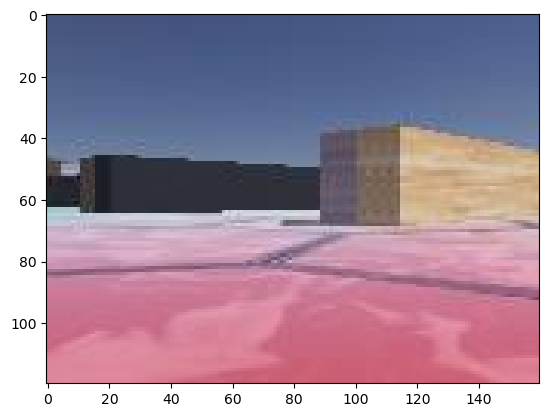

In [19]:
idx = 46
plt.imshow(noReward_dataset[idx])
print("Image shape =", noReward_dataset[idx].shape)

## Dataset exploration (No Reward)

In [153]:
def occupancy_map(XYposition, plot_folder, save=False):
    x_array = XYposition[:, 0]
    y_array = XYposition[:, 1]

    x_bins = 40  # Fewer bins for the X-axis
    y_bins = 40  # Keeping more bins for the Y-axis to maintain aspect ratio
    figsize=(7, 6)

    xedges = np.linspace(np.min(x_array), np.max(x_array), x_bins + 1)
    yedges = np.linspace(np.min(y_array), np.max(y_array), y_bins + 1)

    fig, ax = plt.subplots(figsize=figsize)  # Adjusting the figure size for better aspect ratio
    ax.set_aspect("auto")

    hist, xedges, yedges, im = ax.hist2d(x_array, y_array, bins=[xedges, yedges])
    H = hist.T
    H_normalized = H / float(XYposition.shape[0])

    ax.set_title('DoubleTmaze occupancy map', fontsize=15)
    ax.set_xticks(np.arange(np.min(x_array), np.max(x_array), step=.5))
    ax.set_yticks(np.arange(np.min(y_array), np.max(y_array), step=.25))

    hist_im = ax.imshow(H, origin='lower', extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]], aspect='auto')
    cbar = fig.colorbar(hist_im)
    cbar.set_label('Normal timesteps', rotation=270, fontsize=15, labelpad=+25)

    plt.show()
    if save:
        fig.savefig(plot_folder + '/Occupancy_map.pdf', format='pdf', bbox_inches='tight')
        fig.savefig(plot_folder + '/Occupancy_map.png', format='png')

    return hist


def agent_trajectory(XYposition, plot_folder, save=False):

    obstacle1x =[-1.22, -1.22, -.45, -.45, -1.1, -1.1, -.45, -.45, -1.22, -1.22, -.07, -.07, .07, .07, 1.22, 1.22, .45,
                .45, 1.1, 1.1, .45, .45, 1.22, 1.22, .07, .07, -.07, -.07, -1.22]
    obstacle1y =[-1.2, -.8, -.8, -.7, -.7, .7, .7, .8, .8, 1.2, 1.2, .75, .75, 1.2, 1.2, .8, .8, .7, .7, -.7, -.7, 
                -.8, -.8, -1.2, -1.2, -.75, -.75, -1.2, -1.2]
    obstacle2x = [-.4, -.4, .4, .4, -.4]
    obstacle2y = [-.35, -.2, -.2, -.35, -.35]
    obstacle3x = [-.4, -.4, .4, .4, -.4]
    obstacle3y = [.35, .2, .2, .35, .35]
    obstaclesx = [obstacle1x, obstacle2x,obstacle3x]
    obstaclesy = [obstacle1y, obstacle2y,obstacle3y]

    figsize=(7, 6) 
    fig = plt.figure(figsize=figsize)

    for i in range(len(obstaclesx)):
        plt.plot(obstaclesx[i], obstaclesy[i], linewidth=3, color='grey')

    x_array = XYposition[:, 0]
    y_array = XYposition[:, 1]

    plt.plot(x_array, y_array, linewidth=0.2)
    plt.yticks(np.arange(-2, 2, step=.2), fontsize=10)
    plt.xticks(np.arange(-2, 2, step=.2), fontsize=10)
    plt.title("Agent's trajectory", fontsize=30)
    plt.plot(x_array[0],y_array[0],'ro', markersize=10)
    plt.show()
    
    if save:
        fig.savefig(plot_folder + '/Trajectory.pdf', format='pdf', bbox_inches='tight')
        fig.savefig(plot_folder + '/Trajectory.png', format='png')


def plot_samples_per_bin_hist(hist):
    fig, ax = plt.subplots(figsize=(8, 5))
    
    ax.hist(hist.flatten(), bins=25, color='steelblue', edgecolor='white', linewidth=0.5)
    
    ax.set_title('Histogram of samples per bin', fontsize=14)
    ax.set_xlabel('Num. samples')
    ax.set_ylabel('Bin count')
    ax.spines[['top', 'right']].set_visible(False)
    
    plt.tight_layout()
    plt.show()

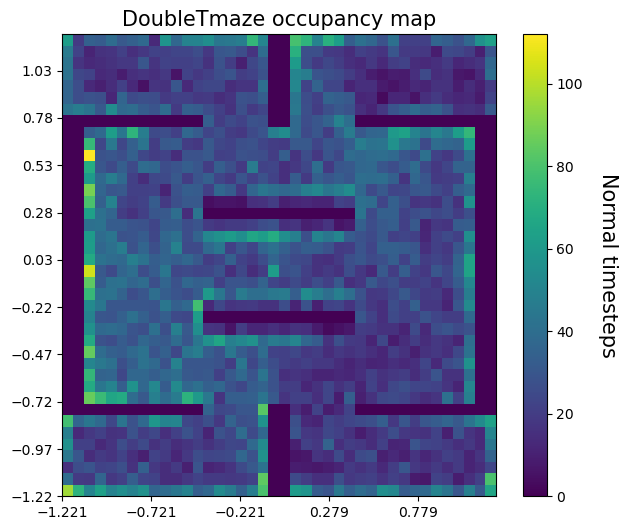

In [155]:
noReward_hist = occupancy_map(noReward_DTmaze_position, plot_folder_path, save=False)

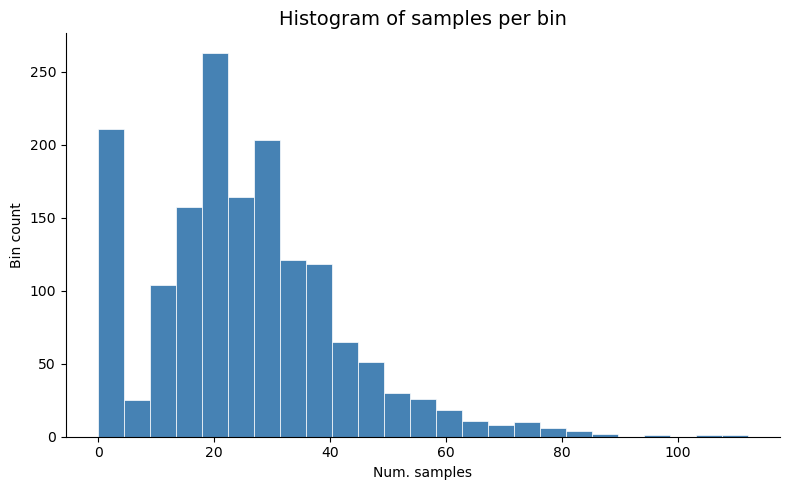

In [157]:
plot_samples_per_bin_hist(noReward_hist)

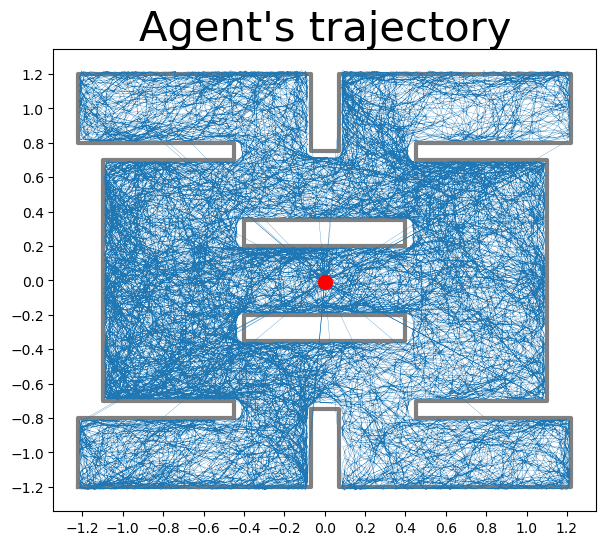

In [159]:
agent_trajectory(noReward_DTmaze_position, plot_folder_path, save=False)

# Train or Load Autoencoder

In [26]:
if model_training == True:
    start_time = time.time()
    model = Conv_AE(n_hidden=n_hidden)
    train_loader = create_dataloader(noReward_dataset, batch_size=batch_size)
    history, _= train_autoencoder(model, train_loader, num_epochs=num_epochs, learning_rate=learning_rate, alpha=alpha, C_factor=C_factor)

    elapsed_time = time.time() - start_time
    hours, remainder = divmod(elapsed_time, 3600)
    minutes, seconds = divmod(remainder, 60)
    timer = "Training duration: " + "{:02}:{:02}:{:02}".format(int(hours), int(minutes), int(seconds))
    print(timer, end="\r")

    #Saving loss history in a CSV file
    save_training_loss(loss_csv_filename, history)

    if model_saving == True:
        print("Autoencoder saved at", model_path)
        torch.save(model.state_dict(), model_path)

### Load

In [28]:
if model_training == False:
    try:
        model = Conv_AE(n_hidden=n_hidden)
        model.load_state_dict(torch.load(model_path))
        print("Model loaded:", model_path)
        history = pd.read_csv(loss_csv_filename)['Image_loss'].tolist()
    except:
      print("An exception occurred - No available Autoencoder")

Model loaded: C:\Users\specs\Desktop\Robotology\Repos\HPC-VTA_Autoencoder/Models/DoubleTmaze-Epochs200-NHidden400-BSize256-C1000.0-A100000.0-LR0.0001.pth


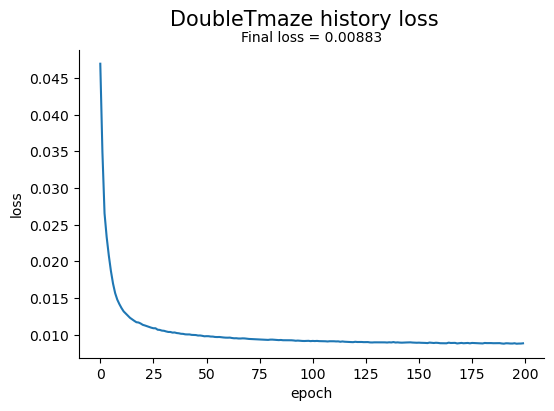

In [29]:
fig = plt.figure(figsize=(6,4))
plt.plot(history)
plt.xlabel('epoch')
plt.ylabel('loss')
sb.despine()
plt.suptitle('DoubleTmaze history loss', fontsize=15)
plt.title('Final loss = ' + str(round(history[-1], 5)), fontsize=10)
plt.show()

X position = 0.127
Y position = 0.177


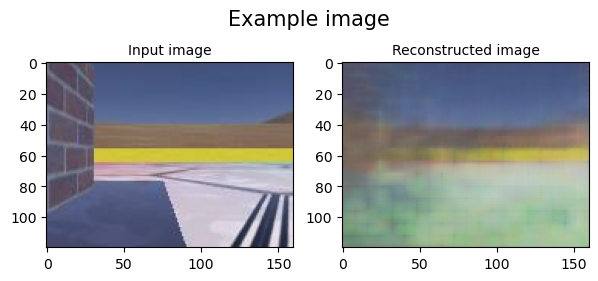

In [30]:
img_indx = 5
print('X position =', round(noReward_DTmaze_position[img_indx][0],3))
print('Y position =', round(noReward_DTmaze_position[img_indx][1],3))

fig = plt.figure(figsize=(7,3))
plt.subplot(121)
plt.imshow(noReward_dataset[img_indx])
plt.suptitle('Example image', fontsize=15)
plt.title('Input image', fontsize=10)
plt.subplot(122)
plt.imshow(predict(noReward_dataset[img_indx], model))
plt.title('Reconstructed image', fontsize=10)

plt.show()

## Evaluating embedding activity (No Reward)

In [32]:
noReward_embeddings = get_latent_vectors(noReward_dataset, model, batch_size=batch_size)

In [33]:
noReward_max_activity = []
noReward_mean_activity = []
activity_threshold = 0.001
noReward_num_active_units = []

for i in range(len(noReward_embeddings)):
    noReward_max_activity.append(np.max(noReward_embeddings[i]))
    noReward_mean_activity.append(np.mean(noReward_embeddings[i]))
    noReward_num_active_units.append(np.sum(noReward_embeddings[i] > activity_threshold))

Mean Embedding Max. Activity = 17.914116
Std. Embedding Max. Activity = 3.3426945


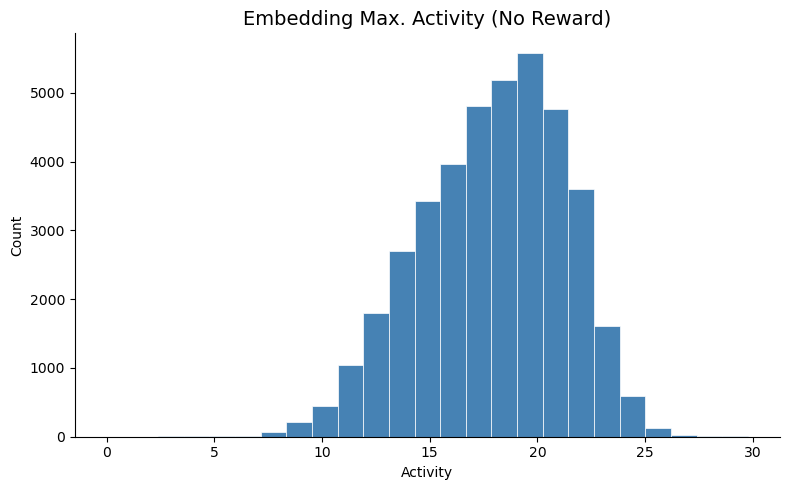

In [161]:
print('Mean Embedding Max. Activity =', np.mean(noReward_max_activity))
print('Std. Embedding Max. Activity =', np.std(noReward_max_activity))

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(noReward_max_activity, bins=25, color='steelblue', edgecolor='white', linewidth=0.5)
ax.set_title('Embedding Max. Activity (No Reward)', fontsize=14)
ax.set_xlabel('Activity')
ax.set_ylabel('Count')
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

Mean Embedding Mean Activity = 0.06369832
Std. Embedding Mean Activity = 0.012902281


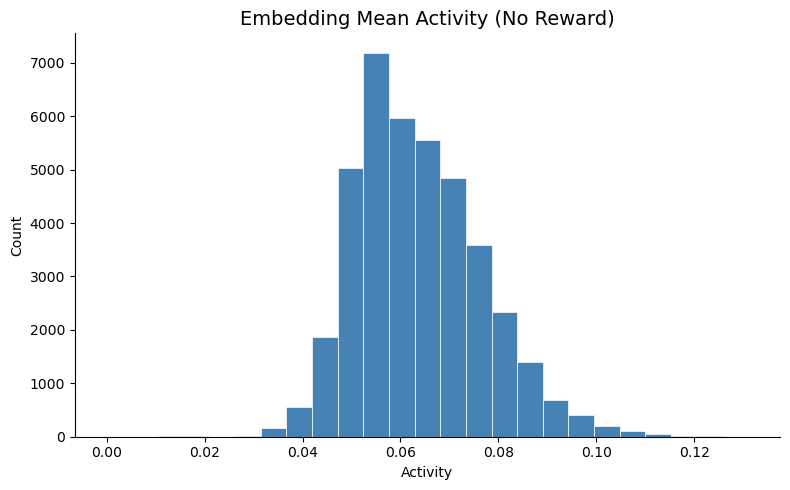

In [35]:
print('Mean Embedding Mean Activity =', np.mean(noReward_mean_activity))
print('Std. Embedding Mean Activity =', np.std(noReward_mean_activity))

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(noReward_mean_activity, bins=25, color='steelblue', edgecolor='white', linewidth=0.5)
ax.set_title('Embedding Mean Activity (No Reward)', fontsize=14)
ax.set_xlabel('Activity')
ax.set_ylabel('Count')
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

Mean Embedding Active Units = 2.5447386184654617
Std. Embedding Active Units = 1.1861607945351103


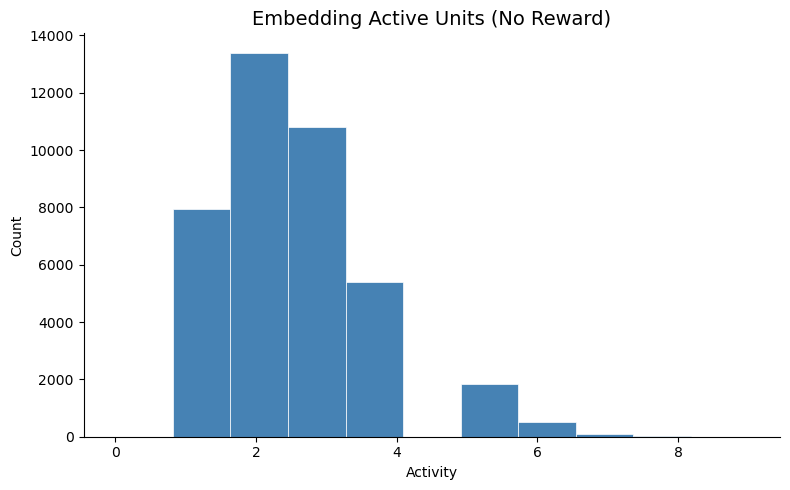

In [36]:
print('Mean Embedding Active Units =', np.mean(noReward_num_active_units))
print('Std. Embedding Active Units =', np.std(noReward_num_active_units))

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(noReward_num_active_units, bins=11, color='steelblue', edgecolor='white', linewidth=0.5)
ax.set_title('Embedding Active Units (No Reward)', fontsize=14)
ax.set_xlabel('Activity')
ax.set_ylabel('Count')
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

## Embedding dynamics in DoubleTmaze

In [ ]:
def reconstruction_loss(model, image, criterion=nn.MSELoss()):
    model.eval()
    with torch.no_grad():
        if image.shape[-1] <= 4:
            image = np.transpose(image, (2, 0, 1))
        n_channels, h, w = image.shape
        image_tensor = torch.from_numpy(image).float().reshape(1, n_channels, h, w).to(next(model.parameters()).device)
        output = model(image_tensor)[0]  # take first element of tuple
        loss = criterion(output, image_tensor)
    return loss.item()

def reconstruction_error_map(model, image):
    model.eval()
    with torch.no_grad():
        if image.shape[-1] <= 4:
            image = np.transpose(image, (2, 0, 1))
        n_channels, h, w = image.shape
        image_tensor = torch.from_numpy(image).float().reshape(1, n_channels, h, w).to(next(model.parameters()).device)
        output = model(image_tensor)[0]
        error_map = ((output - image_tensor) ** 2).squeeze(0).mean(0)  # average over channels
    return error_map.cpu().numpy()  # shape (h, w)

# Introduction of Reward Dataset

In [38]:
data_path = 'D:\HPC-VTA_autoencoder_data\DoubleTmazeDataset\DoubleTmazeWithReward'
#data_path = 'D:\HPC-VTA_autoencoder_data\DoubleTmazeDataset\DoubleTmazeNoReward2'
csv_filename, num_images = format_dataset(data_path)

print("Num. Images in Dataset =", num_images)
print("Dataset Path =", data_path)
print("CSV path =    ", csv_filename)

Num. Images in Dataset = 40000
Dataset Path = D:\HPC-VTA_autoencoder_data\DoubleTmazeDataset\DoubleTmazeNoReward2
CSV path =     D:\HPC-VTA_autoencoder_data\DoubleTmazeDataset\DoubleTmazeNoReward2/data.csv


In [39]:
withReward_dataset = load_dataset(data_path)  # this array should have shape (n_samples, 3, 120, 160)
withReward_DTmaze_data, withReward_DTmaze_position, withReward_DTmaze_orientation = load_csv(csv_filename)

frames_to_remove = check_missing_frame(withReward_DTmaze_data)
withReward_dataset = clean_dataset(withReward_dataset, frames_to_remove)

print("Dataset Shape =", withReward_dataset.shape)
print("Position Shape =", withReward_DTmaze_position.shape)
print()
withReward_DTmaze_data

Frames ID to be removed from dataset = [35753]
Dataset Shape = (39999, 120, 160, 3)
Position Shape = (39999, 2)



,Trial_number,Trial_time,Frame_ID,Embedding,action,retrieved_action,X,Y,Z,Internal_states,RewardID,Reward_value,n_replays
0,0,1.024,1,[],"[0, 0]",False,-0.000008,-0.009500,270.045416,"[0.999, 0.999, 0.499, 0.999]",0,"[0, 0, 0, 0]",0
1,0,2.048,2,[],"[3.14, 4.71]",False,0.014773,0.063646,300.698986,"[0.998, 0.998, 0.498, 0.998]",0,"[0, 0, 0, 0]",0
2,0,3.072,3,[],"[6.28, 6.28]",False,0.081278,0.171943,301.562288,"[0.997, 0.997, 0.497, 0.997]",0,"[0, 0, 0, 0]",0
3,0,4.096,4,[],"[1.57, 3.14]",False,0.112494,0.183708,332.673683,"[0.996, 0.996, 0.496, 0.996]",0,"[0, 0, 0, 0]",0
4,0,5.120,5,[],"[1.57, 3.14]",False,0.158347,0.188660,4.988723,"[0.995, 0.995, 0.495, 0.995]",0,"[0, 0, 0, 0]",0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
39994,40,1684.480,39996,[],"[1.57, 0.0]",False,-0.949096,-1.212840,1.498599,"[0.0001, 0.0001, 0.0001, 0.0001]",0,"[0, 0, 0, 0]",0
39995,40,1685.504,39997,[],"[1.57, 0.0]",False,-0.931764,-1.213850,328.062598,"[0.0001, 0.0001, 0.0001, 0.0001]",0,"[0, 0, 0, 0]",0
39996,40,1686.528,39998,[],"[5.5, 6.28]",False,-0.830556,-1.163206,342.414682,"[0.0001, 0.0001, 0.0001, 0.0001]",0,"[0, 0, 0, 0]",0
39997,40,1687.552,39999,[],"[6.28, 4.71]",False,-0.734297,-1.111483,314.166358,"[0.0001, 0.0001, 0.0001, 0.0001]",0,"[0, 0, 0, 0]",0


Image shape = (120, 160, 3)


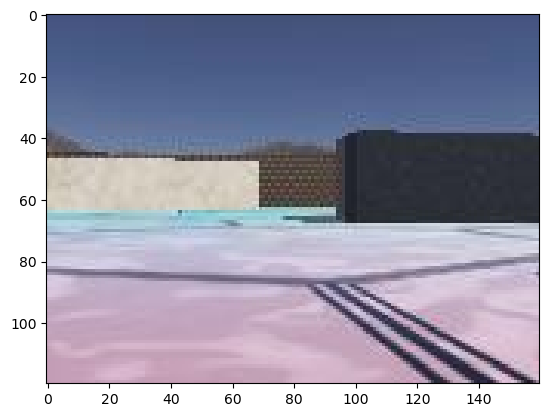

In [40]:
idx = 72
plt.imshow(withReward_dataset[idx])
print("Image shape =", withReward_dataset[idx].shape)

## Dataset exploration (With Reward)

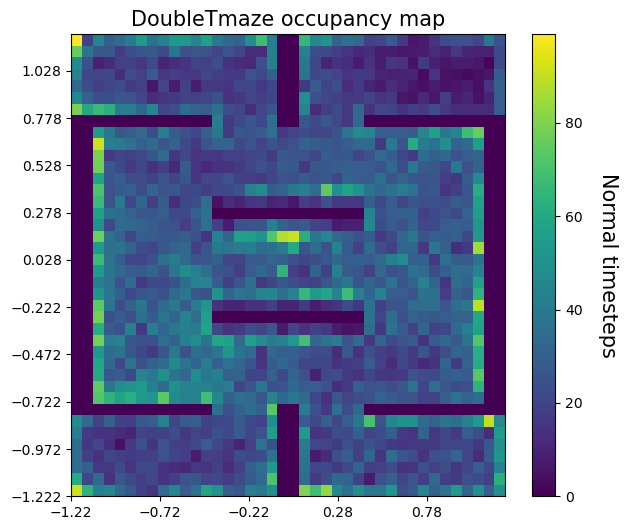

In [163]:
withReward_hist = occupancy_map(withReward_DTmaze_position, plot_folder_path, save=False)

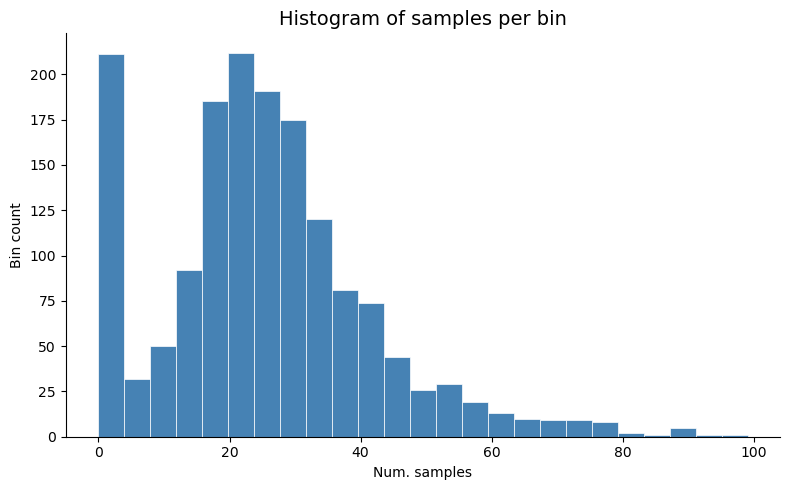

In [165]:
plot_samples_per_bin_hist(withReward_hist)

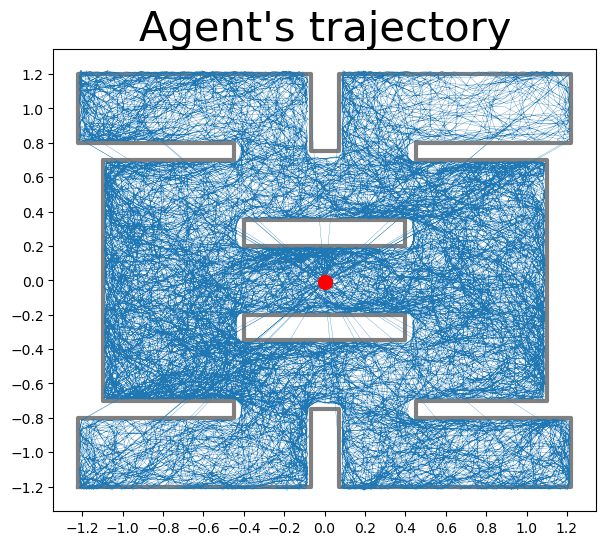

In [44]:
agent_trajectory(withReward_DTmaze_position, plot_folder_path, save=False)

## Evaluating embedding activity (With Reward)

In [46]:
withReward_embeddings = get_latent_vectors(withReward_dataset, model, batch_size=batch_size)

In [47]:
withReward_max_activity = []
withReward_mean_activity = []
activity_threshold = 0.001
withReward_num_active_units = []

for i in range(len(withReward_embeddings)):
    withReward_max_activity.append(np.max(withReward_embeddings[i]))
    withReward_mean_activity.append(np.mean(withReward_embeddings[i]))
    withReward_num_active_units.append(np.sum(withReward_embeddings[i] > activity_threshold))

Mean Embedding Max. Activity = 17.480824
Std. Embedding Max. Activity = 3.6671531


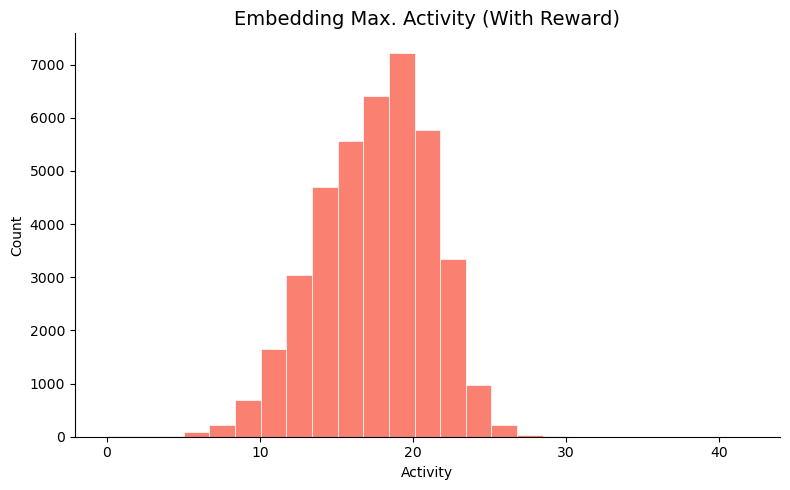

In [48]:
print('Mean Embedding Max. Activity =', np.mean(withReward_max_activity))
print('Std. Embedding Max. Activity =', np.std(withReward_max_activity))

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(withReward_max_activity, bins=25, color='salmon', edgecolor='white', linewidth=0.5)
ax.set_title('Embedding Max. Activity (With Reward)', fontsize=14)
ax.set_xlabel('Activity')
ax.set_ylabel('Count')
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

Mean Embedding Mean Activity = 0.06358529
Std. Embedding Mean Activity = 0.013465879


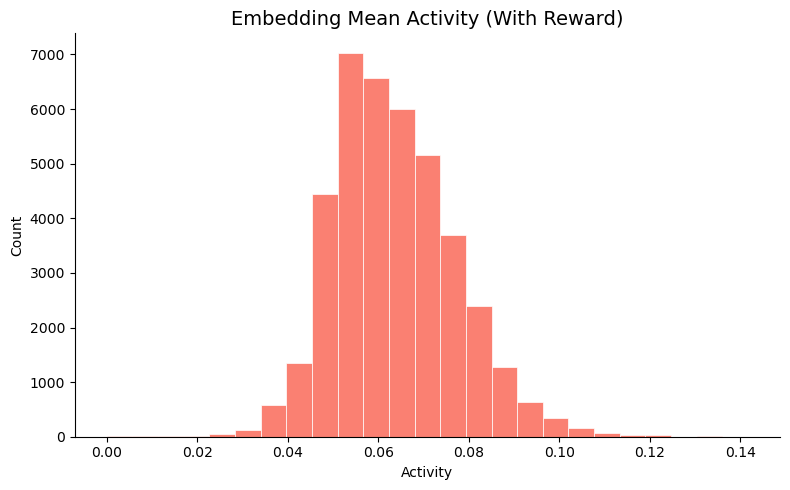

In [49]:
print('Mean Embedding Mean Activity =', np.mean(withReward_mean_activity))
print('Std. Embedding Mean Activity =', np.std(withReward_mean_activity))

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(withReward_mean_activity, bins=25, color='salmon', edgecolor='white', linewidth=0.5)
ax.set_title('Embedding Mean Activity (With Reward)', fontsize=14)
ax.set_xlabel('Activity')
ax.set_ylabel('Count')
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

Mean Embedding Active Units = 2.624615615390385
Std. Embedding Active Units = 1.1996462251029678


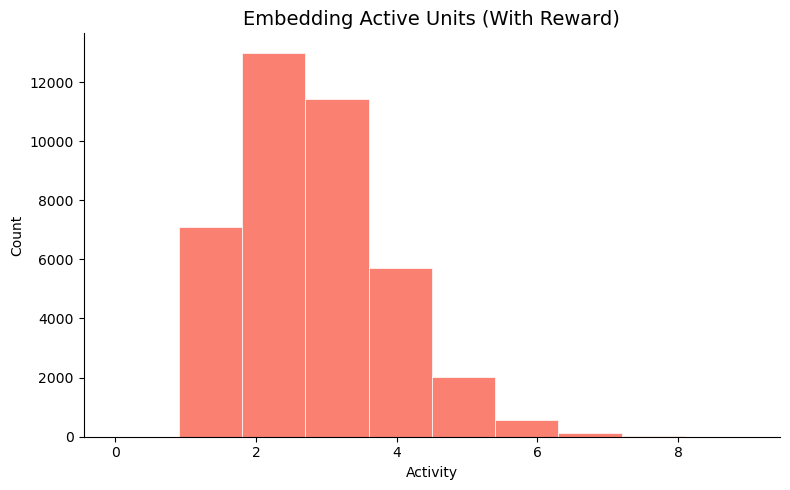

In [50]:
print('Mean Embedding Active Units =', np.mean(withReward_num_active_units))
print('Std. Embedding Active Units =', np.std(withReward_num_active_units))

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(withReward_num_active_units, bins=10, color='salmon', edgecolor='white', linewidth=0.5)
ax.set_title('Embedding Active Units (With Reward)', fontsize=14)
ax.set_xlabel('Activity')
ax.set_ylabel('Count')
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

## Searching for novelty signatures in model's embedding

We are going to explore:
- Embedding max activity.
- Embedding mean activity.
- Num. of active units in the embedding.
- Model MSE Reconstruction Loss. How good the model reconstruct new inputs.
- Model Reconstruction Error Map. Maximal (percentil 98) partial loss within the sample.

Yet to do:
- Population vector distance.
- Population sparsity.
- Activation entropy.
- Unit recruitment novelty.

Embedding max activity = 19.266766
Embedding mean activity = 0.048166916
Num. active units = 1


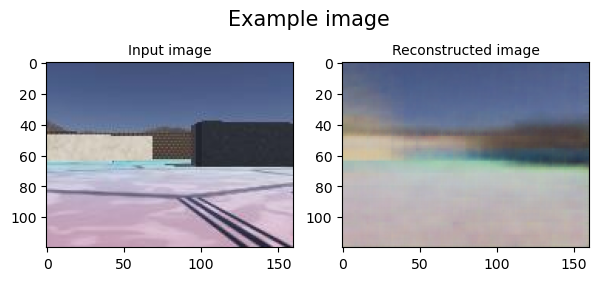

In [52]:
img_indx = 72
print('Embedding max activity =' , np.max(withReward_embeddings[img_indx]))
print('Embedding mean activity =' , np.mean(withReward_embeddings[img_indx]))
print('Num. active units =' , np.sum(withReward_embeddings[img_indx] > activity_threshold))

fig = plt.figure(figsize=(7,3))
plt.subplot(121)
plt.imshow(withReward_dataset[img_indx])
plt.suptitle('Example image', fontsize=15)
plt.title('Input image', fontsize=10)
plt.subplot(122)
plt.imshow(predict(withReward_dataset[img_indx], model))
plt.title('Reconstructed image', fontsize=10)

plt.show()

In [54]:
sample_loss = []
for i in range(len(withReward_dataset)):
    sample_loss.append(reconstruction_loss(model, withReward_dataset[i]))

In [55]:
sample_error_map = []
for i in range(len(withReward_dataset)):
    error_map = reconstruction_error_map(model, withReward_dataset[i])
    sample_error_map.append(np.percentile(error_map, 98))

In [56]:
relative_max_activity = []
relative_mean_activity = []
relative_num_active_units = []
relative_sample_loss = []
relative_error_map = []

for i in range(len(withReward_embeddings)):
    relative_max_activity.append(np.max(withReward_embeddings[i]) - np.mean(withReward_max_activity))
    relative_mean_activity.append(np.mean(withReward_embeddings[i]) - np.mean(withReward_mean_activity))
    relative_num_active_units.append(np.sum(withReward_embeddings[i] > activity_threshold) - np.mean(withReward_num_active_units))
    relative_sample_loss.append(sample_loss[i] - np.mean(sample_loss))
    relative_error_map.append(sample_error_map[i] - np.mean(sample_error_map))

In [145]:
def value_heatmap(XYposition, values, title=""):
    x_array = XYposition[:, 0]
    y_array = XYposition[:, 1]
    x_bins = 40
    y_bins = 40
    figsize = (7, 6)

    xedges = np.linspace(np.min(x_array), np.max(x_array), x_bins + 1)
    yedges = np.linspace(np.min(y_array), np.max(y_array), y_bins + 1)

    # Average value per bin instead of counting
    stat, xedges, yedges, _ = binned_statistic_2d(
        x_array, y_array, values, statistic='mean', bins=[xedges, yedges]
    )

    fig, ax = plt.subplots(figsize=figsize)
    ax.set_aspect('auto')

    vmax = np.nanmax(np.abs(stat))  # symmetric colorscale
    im = ax.imshow(
        stat.T, origin='lower',
        extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
        aspect='auto',
        cmap='RdBu_r',  # blue=negative, red=positive
        vmin=-vmax, vmax=vmax
    )

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label('Relative value (with respect the mean)', rotation=270, fontsize=15, labelpad=25)
    ax.set_title(title + ' Value Heatmap', fontsize=15)
    plt.show()
    
    return stat

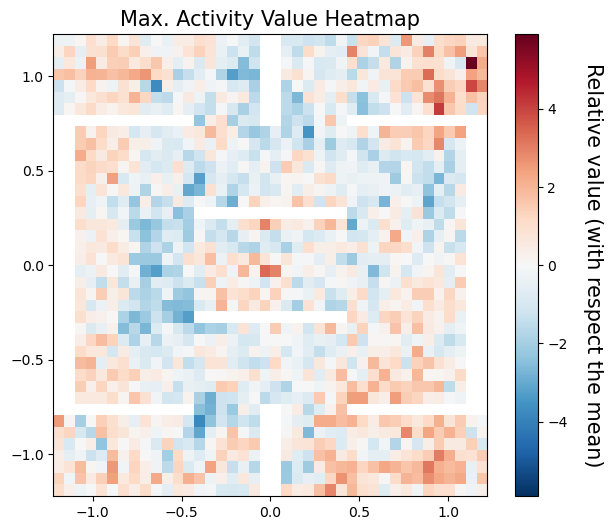

In [147]:
heatmap = value_heatmap(withReward_DTmaze_position, relative_max_activity, title="Max. Activity")

In [151]:
heatmap.shape

(40, 40)

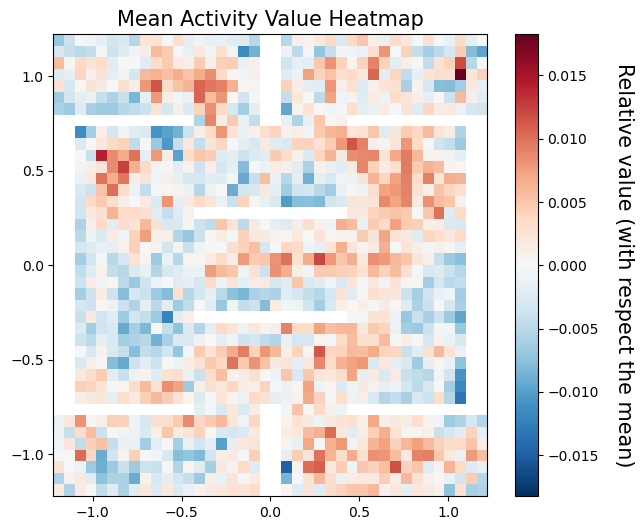

In [59]:
value_heatmap(withReward_DTmaze_position, relative_mean_activity, title="Mean Activity")

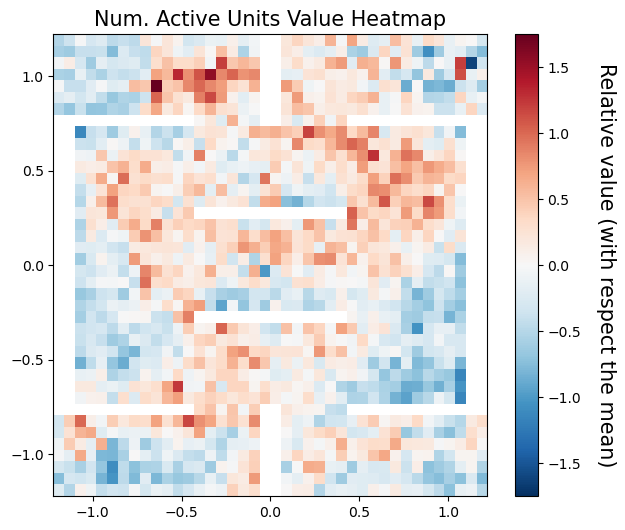

In [60]:
value_heatmap(withReward_DTmaze_position, relative_num_active_units, title="Num. Active Units")

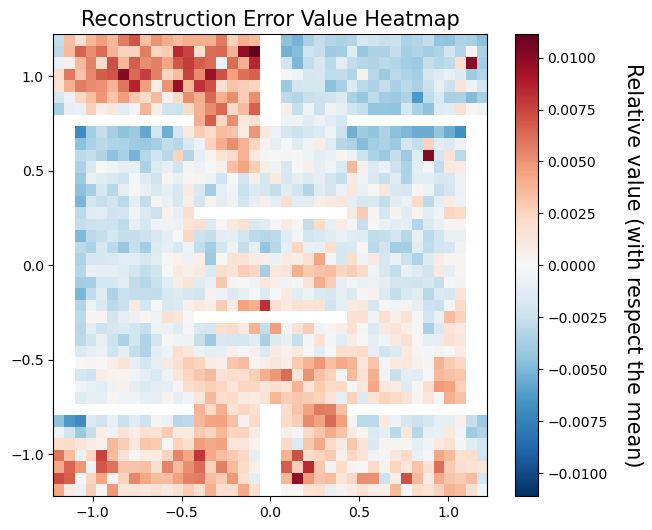

In [61]:
value_heatmap(withReward_DTmaze_position, relative_sample_loss, title="Reconstruction Error")

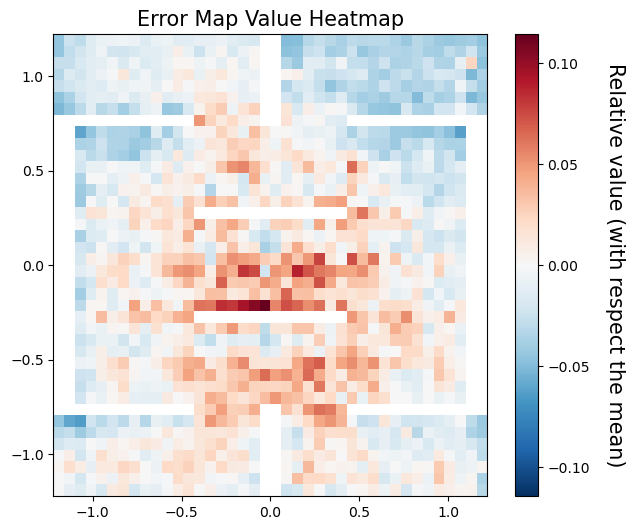

In [62]:
value_heatmap(withReward_DTmaze_position, relative_error_map, title="Error Map")

In [63]:
def oriented_value_heatmap(XYposition, values, orientations, angle_range=48.1, title="", gaussian=True):
    x_array = XYposition[:, 0]
    y_array = XYposition[:, 1]
    values     = np.array(values)
    orientations = np.array(orientations)

    # Center of the environment
    cx = (np.min(x_array) + np.max(x_array)) / 2
    cy = (np.min(y_array) + np.max(y_array)) / 2

    # Angle from each position toward the center
    dx = cx - x_array
    dy = cy - y_array
    angle_to_center = np.degrees(np.arctan2(dy, dx))

    # Angular difference, wrapped to [-180, 180]
    angle_diff = (orientations - angle_to_center + 180) % 360 - 180

    # Filter
    mask = np.abs(angle_diff) <= (angle_range / 2)
    x_array  = x_array[mask]
    y_array  = y_array[mask]
    values   = values[mask]
    
    x_bins = 100
    y_bins = 100
    figsize = (7, 6)

    xedges = np.linspace(np.min(x_array), np.max(x_array), x_bins + 1)
    yedges = np.linspace(np.min(y_array), np.max(y_array), y_bins + 1)

    # Average value per bin instead of counting
    stat, xedges, yedges, _ = binned_statistic_2d(
        x_array, y_array, values, statistic='mean', bins=[xedges, yedges]
    )

    if gaussian:
        stat = gaussian_filter(np.nan_to_num(stat), sigma=2)

    fig, ax = plt.subplots(figsize=figsize)
    ax.set_aspect('auto')

    vmax = np.nanmax(np.abs(stat))  # symmetric colorscale
    im = ax.imshow(
        stat.T, origin='lower',
        extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
        aspect='auto',
        cmap='RdBu_r',  # blue=negative, red=positive
        vmin=-vmax, vmax=vmax
    )

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label('Value', rotation=270, fontsize=15, labelpad=25)
    ax.set_title(title + ' Reward-oriented Value heatmap', fontsize=15)
    plt.show()

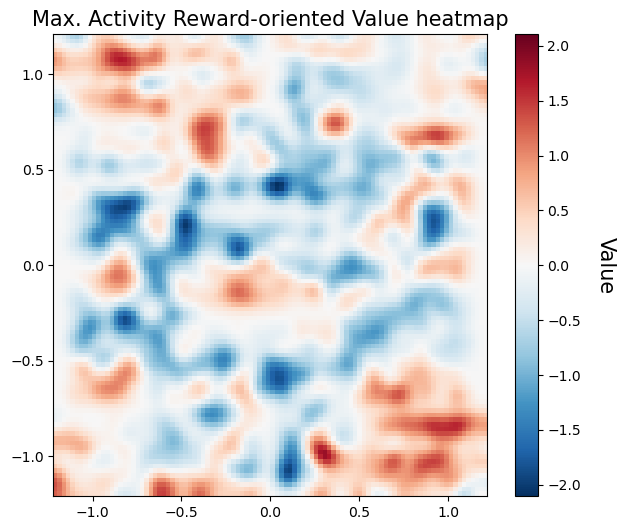

In [64]:
oriented_value_heatmap(withReward_DTmaze_position, relative_max_activity, withReward_DTmaze_orientation, title="Max. Activity")

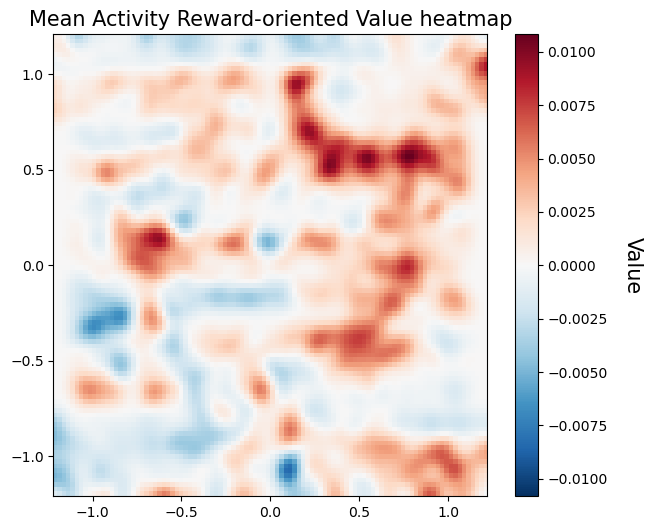

In [65]:
oriented_value_heatmap(withReward_DTmaze_position, relative_mean_activity, withReward_DTmaze_orientation, title="Mean Activity")

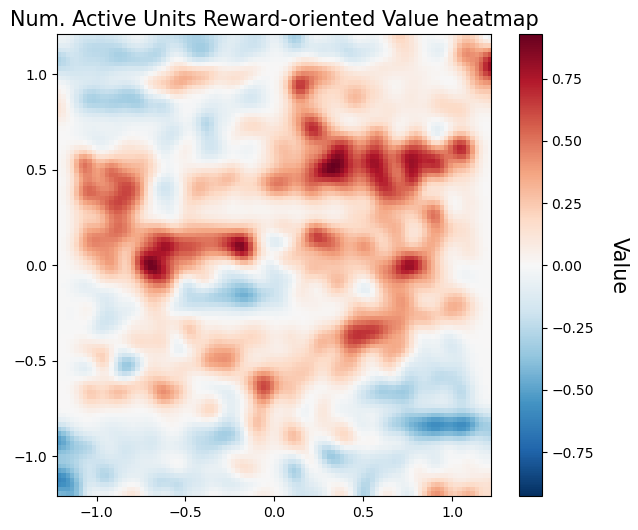

In [66]:
oriented_value_heatmap(withReward_DTmaze_position, relative_num_active_units, withReward_DTmaze_orientation, title="Num. Active Units")

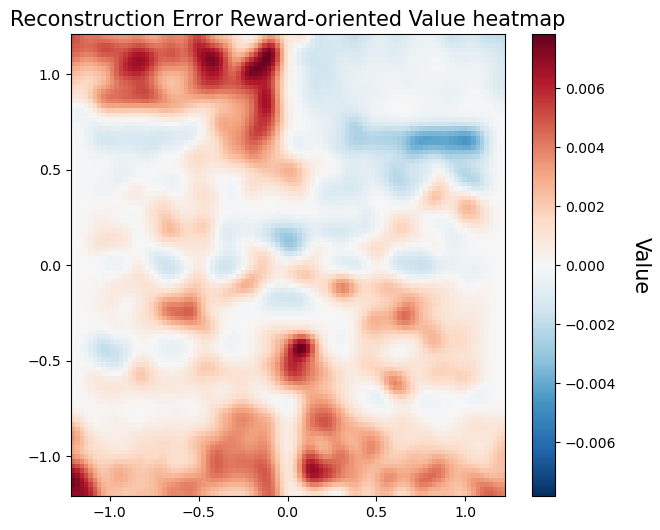

In [67]:
oriented_value_heatmap(withReward_DTmaze_position, relative_sample_loss, withReward_DTmaze_orientation, title="Reconstruction Error")

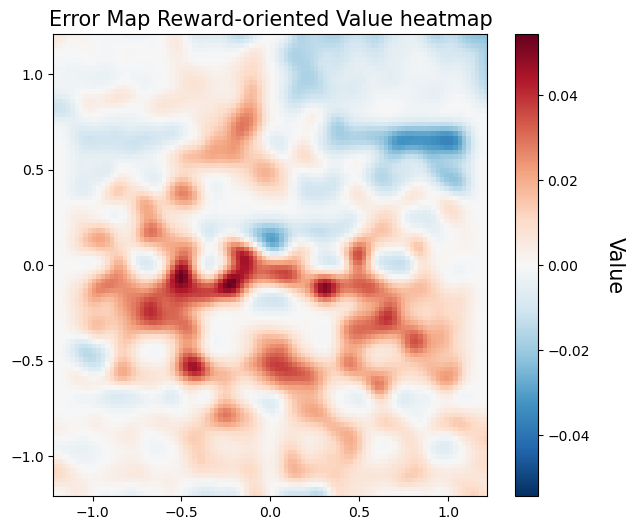

In [68]:
oriented_value_heatmap(withReward_DTmaze_position, relative_error_map, withReward_DTmaze_orientation, title="Error Map")

In [69]:
n = withReward_embeddings.shape[1]
l2 = np.sqrt((withReward_embeddings**2).sum(axis=1))
l2 = np.where(l2 == 0, np.nan, l2)  # zero-activation images become NaN instead of inf
sparsity = (np.sqrt(n) - withReward_embeddings.sum(axis=1) / l2) / (np.sqrt(n) - 1)

In [70]:
relative_sparsity = []

for i in range(len(withReward_embeddings)):
    relative_sparsity.append(sparsity[i] - np.nanmean(sparsity))

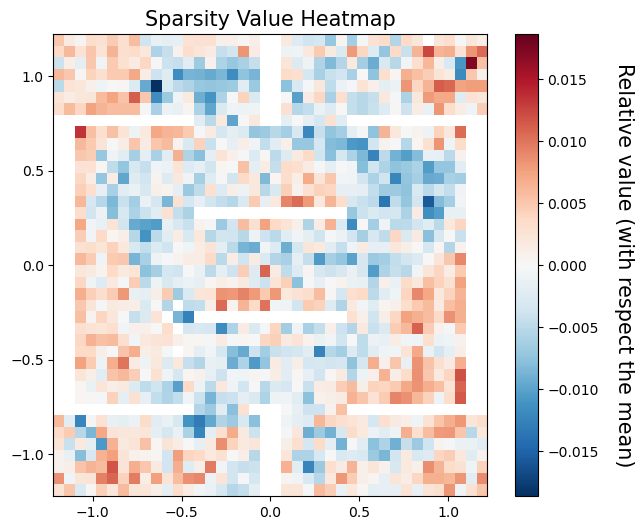

In [71]:
value_heatmap(withReward_DTmaze_position, relative_sparsity, title="Sparsity")

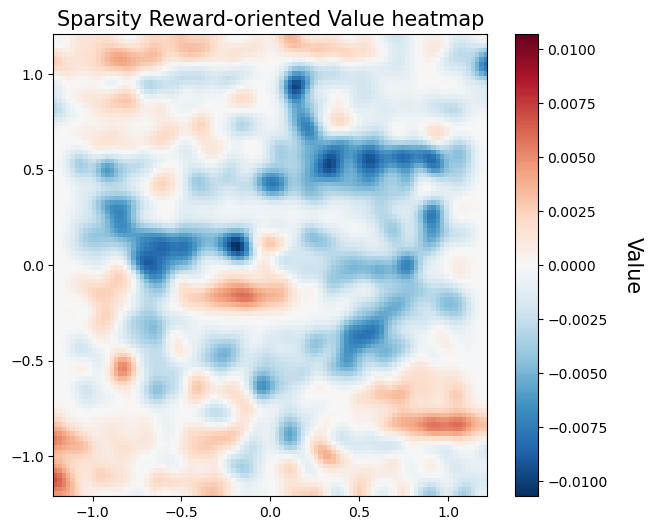

In [72]:
oriented_value_heatmap(withReward_DTmaze_position, relative_sparsity, withReward_DTmaze_orientation, title="Sparsity")

In [73]:
from scipy.stats import entropy
def safe_entropy(v):
    s = v.sum()
    if s == 0:
        return np.nan
    return entropy(v / s)

entropies = np.array([safe_entropy(withReward_embeddings[i]) for i in range(len(withReward_embeddings))])

print(np.nanmean(entropies))
print(np.isnan(entropies).sum())

0.6190104587036567
6


In [74]:
relative_entropies = []

for i in range(len(withReward_embeddings)):
    relative_entropies.append(entropies[i] - np.nanmean(entropies))

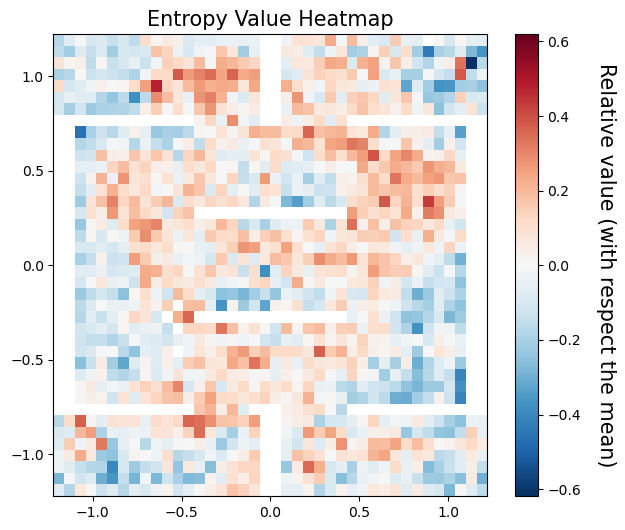

In [75]:
value_heatmap(withReward_DTmaze_position, relative_entropies, title="Entropy")

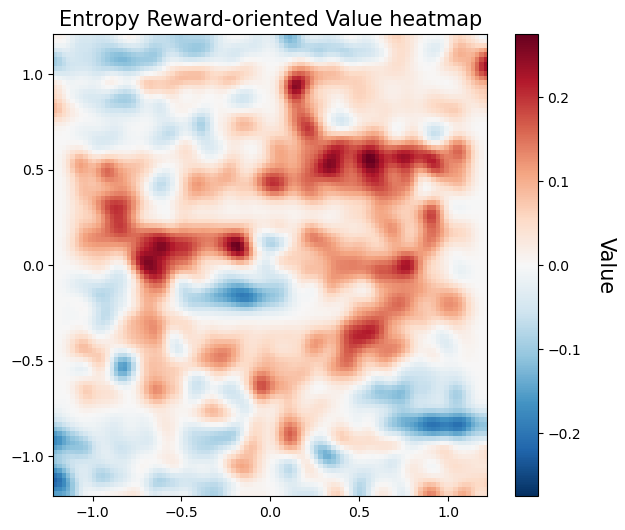

In [76]:
oriented_value_heatmap(withReward_DTmaze_position, relative_entropies, withReward_DTmaze_orientation, title="Entropy")